#### Supp. Fig 7 c, d, e

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import torch 
import os

pd.set_option('display.max_columns',500)
pd.set_option('display.max_categories',60)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 14,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 14,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 10  # Padding for title
})

In [2]:
save_dir = "mayr_figs"
os.makedirs(save_dir, exist_ok=True)

In [3]:
h5ad_savedir = "h5ad"
os.makedirs(h5ad_savedir, exist_ok=True)

In [5]:
adata_vis = sc.read_h5ad("./adata_vis_human_spatial_paper.h5ad")


In [6]:
adata_vis.obs

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,leiden_25,sampleID,treatment,VisiumSlides,technology,patient,AT0,AT1,AT2,Aberrant basaloid,Adventitial fibroblast,Alveolar fibroblast,Artery,B/Plasma,Basal,Basophil/Mast,Bronchial Vessel,Capillary,Capillary Aerocyte,Ciliated,Ciliated SFTPB+/SCGB1A1+,Dendritic,Ionocyte,Lymphatic,Macrophage C1Q hi,Macrophage CHI3L1+/CD9 hi/,Macrophage FABP4+,Macrophage IL1B+,Macrophage LYVE1+,Macrophage RETN+/VCAN+,Mesothelial,Monocyte,Mucous,Myofibroblast,NK,Peribronchial fibroblast,Pericyte,Smooth Muscle,T cell,TB-SC,Vein,pDC,preTB-SC/RAS,Androgen,EGFRsignaling,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,p53,PI3K,TGFb,TNFa,Trail,VEGF,WNT,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,Niche_NMF
spot_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
90_A1_H237762_IPF_processed_CM_AAACAAGTATCTCCCA-1,1,50,102,90_A1_H237762_IPF_processed_CM,2869,7.962067,5180.0,8.552753,24,90_A1_H237762_IPF_processed_CM,IPF,90,Visium,Donor_IPF_1,0.001162,0.012275,0.000589,0.002108,0.203605,1.176494,0.027367,0.824555,0.265306,0.053716,0.052077,0.059858,0.021229,0.606597,0.022317,0.022690,0.020689,0.056351,0.007480,0.005052,0.006702,0.032065,0.024179,0.004730,0.032692,0.005560,0.335918,0.003276,0.014663,0.043533,0.221838,0.147173,0.034529,0.001803,0.106638,0.008943,0.002292,2.650245,2.292592,-1.646316,3.644362,-1.347805,-7.623316,-1.350011,-0.147144,3.104962,0.419288,2.356944,-0.188570,3.564424,-2.178154,0.109000,0.000000,0.000000,2.004795,0.0,0.979459,0.000000,1.029371,0.000000,1.429611,Fibroblast
90_A1_H237762_IPF_processed_CM_AAACACCAATAACTGC-1,1,59,19,90_A1_H237762_IPF_processed_CM,3827,8.250098,7457.0,8.917043,10,90_A1_H237762_IPF_processed_CM,IPF,90,Visium,Donor_IPF_1,0.284728,0.797208,0.466162,0.047545,0.064358,0.038488,0.030167,0.072710,0.001503,0.004011,0.017741,0.213482,0.490113,0.020289,0.000708,0.011706,0.017188,0.026939,0.149093,0.019429,0.217331,0.019013,0.011221,0.059635,0.001773,0.028275,0.000799,0.382100,0.137339,0.054350,0.763590,0.010048,0.034626,0.005220,0.010705,0.020047,0.002497,3.041341,3.419019,-5.230870,4.501948,1.666614,-7.316847,-2.041252,-1.580704,1.601917,3.852517,2.282794,-1.093079,3.115489,-1.783444,0.000000,3.705124,0.000000,0.000000,0.0,0.000000,0.377536,0.000000,0.000000,0.000000,Alveolar
90_A1_H237762_IPF_processed_CM_AAACAGCTTTCAGAAG-1,1,43,9,90_A1_H237762_IPF_processed_CM,3593,8.187021,7115.0,8.870101,11,90_A1_H237762_IPF_processed_CM,IPF,90,Visium,Donor_IPF_1,0.006953,0.053596,0.013402,0.002963,0.061115,0.068147,0.065031,0.011949,0.001548,0.008882,0.020218,1.679387,0.279551,0.000084,0.000110,0.034859,0.001128,0.006098,0.085615,0.012228,0.436892,0.009228,0.070640,0.045646,0.002982,0.142702,0.000171,0.587144,0.059556,0.016156,1.338197,0.083706,0.073377,0.001867,0.006160,0.004211,0.000564,2.872213,2.927256,-2.357574,4.622685,3.492138,-6.250304,-4.030332,-1.421686,4.060267,5.276704,4.226720,-0.612032,2.607534,-2.481025,0.004348,3.263140,0.181226,0.312994,0.0,0.000000,0.654990,0.000000,0.000000,0.000000,Alveolar
90_A1_H237762_IPF_processed_CM_AAACAGGGTCTATATT-1,1,47,13,90_A1_H237762_IPF_processed_CM,3108,8.042056,5879.0,8.679312,26,90_A1_H237762_IPF_processed_CM,IPF,90,Visium,Donor_IPF_1,0.004011,0.052910,0.002612,0.035115,0.070470,0.676508,0.018409,0.302522,0.000960,0.181993,0.015265,0.043379,0.037011,0.000091,0.000180,0.012462,0.003988,0.014203,0.007196,0.006768,0.071575,0.012152,0.005461,0.249340,0.027372,0.018771,0.000610,0.481221,0.030098,0.305133,0.034607,1.580754,0.189599,0.004437,0.026316,0.027901,0.007598,2.795341,2.883236,-2.600745,5.119619,-0.083104,-6.842210,-1.133910,-1.058497,3.209998,6.312673,1.650926,-0.604407,0.775243,-1.537520,1.843619,0.000000,0.000000,1.081668,0.0,0.000000,0.470299,0.351993,0.00

In [7]:
adata_vis.obs[adata_vis.obs['Niche_NMF'] == "Macrophage_SPP1"]

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,leiden_25,sampleID,treatment,VisiumSlides,technology,patient,AT0,AT1,AT2,Aberrant basaloid,Adventitial fibroblast,Alveolar fibroblast,Artery,B/Plasma,Basal,Basophil/Mast,Bronchial Vessel,Capillary,Capillary Aerocyte,Ciliated,Ciliated SFTPB+/SCGB1A1+,Dendritic,Ionocyte,Lymphatic,Macrophage C1Q hi,Macrophage CHI3L1+/CD9 hi/,Macrophage FABP4+,Macrophage IL1B+,Macrophage LYVE1+,Macrophage RETN+/VCAN+,Mesothelial,Monocyte,Mucous,Myofibroblast,NK,Peribronchial fibroblast,Pericyte,Smooth Muscle,T cell,TB-SC,Vein,pDC,preTB-SC/RAS,Androgen,EGFRsignaling,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,p53,PI3K,TGFb,TNFa,Trail,VEGF,WNT,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,Niche_NMF
spot_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
90_A1_H237762_IPF_processed_CM_ATCAGGTAGCTGACAG-1,1,33,127,90_A1_H237762_IPF_processed_CM,3086,8.034955,6175.0,8.728426,3,90_A1_H237762_IPF_processed_CM,IPF,90,Visium,Donor_IPF_1,0.035824,0.119242,0.026210,0.003404,0.023018,0.409068,0.237544,0.168659,0.001653,0.012008,0.015507,0.081843,0.069787,0.000156,0.000110,0.009714,0.004463,0.034062,0.206719,0.893830,0.361264,0.039699,0.126441,0.016105,0.002951,0.015027,0.000473,0.052567,0.018390,0.223456,0.367276,0.006595,0.048736,0.011422,0.009993,0.002613,0.002459,1.829195,2.303094,-3.092649,3.881471,2.840490,-6.752144,-1.190444,-1.742410,3.039655,3.458937,2.145201,-1.740878,2.985413,-1.781548,0.000000,0.600033,0.249056,0.699244,0.790191,0.000000,0.000000,0.092222,0.016132,0.364505,Macrophage_SPP1
90_A1_H237762_IPF_processed_CM_ATCGCTTTACGTCTCA-1,1,35,125,90_A1_H237762_IPF_processed_CM,3079,8.032685,5886.0,8.680502,32,90_A1_H237762_IPF_processed_CM,IPF,90,Visium,Donor_IPF_1,0.100432,0.127474,0.133392,0.038395,0.098544,0.246225,0.053500,0.194076,0.002727,0.004207,0.014536,0.048082,0.154423,0.000539,0.000256,0.005493,0.005796,0.005181,0.011287,1.664142,0.161368,0.023098,0.005509,0.024858,0.004738,0.021009,0.000484,0.164560,0.086857,0.040149,0.632553,0.009138,0.029733,0.006938,0.012576,0.028479,0.001674,1.902974,2.777030,-4.505582,3.465168,3.053108,-6.723817,-2.524715,-0.823956,0.452284,1.377040,3.296781,-0.912116,2.881143,-1.006357,0.000000,1.012214,0.027199,0.442761,1.543916,0.000000,0.087814,0.115395,0.000000,0.101576,Macrophage_SPP1
90_A1_H237762_IPF_processed_CM_ATGTTTCGGCCCGGAG-1,1,33,125,90_A1_H237762_IPF_processed_CM,3389,8.128585,7681.0,8.946635,23,90_A1_H237762_IPF_processed_CM,IPF,90,Visium,Donor_IPF_1,0.021248,0.080796,0.022165,0.001253,0.060759,0.155476,0.008940,0.093605,0.001099,0.003147,0.006312,0.037069,0.174308,0.000379,0.000205,0.001906,0.049855,0.002267,0.033868,2.719713,0.804336,0.006568,0.002669,0.007122,0.014366,0.003327,0.000091,0.143056,0.014884,0.018457,0.087719,0.037994,0.024396,0.001322,0.003505,0.000934,0.000588,2.042089,2.481910,-2.951359,2.962349,4.825239,-6.374272,-2.856850,-1.552503,2.497853,0.736600,3.845561,-1.779227,3.025457,-1.586807,0.000000,0.347064,0.730882,0.122418,2.591288,0.000000,0.036104,0.000000,0.000000,0.044574,Macrophage_SPP1
90_A1_H237762_IPF_processed_CM_CAGGACAGCTGCCCTT-1,1,35,127,90_A1_H237762_IPF_processed_CM,3801,8.243283,8141.0,9.004791,23,90_A1_H237762_IPF_processed_CM,IPF,90,Visium,Donor_IPF_1,0.100535,0.054787,0.110123,0.023996,0.033076,0.032767,0.019474,0.116298,0.001911,0.003521,0.050410,0.137513,0.206335,0.000231,0.000439,0.009427,0.003491,0.003893,0.010786,2.585302,0.540883,0.015516,0.014407,0.048558,0.001695,0.015729,0.000457,0.197501,0.067567,0.084318,0.120072,0.011831,0.044110,0.003618,0.012799,0.013542,0.001383,2.067934,3.197894,-4.325811,5.035485,3.526094,-6.394267,-3.129443,0.067463,2.310920,1.004192,4.483626,-1.425229,4.014897,-1.138803,0.000000,0.640499,0.444142,0.000000,2

In [ ]:
adata_vis.obs["SMCs_Adv_Meso"] = adata_vis.obs["mean_nUMI_factorsfact_0"]
adata_vis.obs["Alveolar"] = adata_vis.obs["mean_nUMI_factorsfact_1"]
adata_vis.obs["Macrophage_FABP4"] = adata_vis.obs["mean_nUMI_factorsfact_2"]
adata_vis.obs["Fibroblast"] = adata_vis.obs["mean_nUMI_factorsfact_3"]
adata_vis.obs["Macrophage_SPP1"] = adata_vis.obs["mean_nUMI_factorsfact_4"]
adata_vis.obs["Airway"] = adata_vis.obs["mean_nUMI_factorsfact_5"]
adata_vis.obs["Fibrotic"] = adata_vis.obs["mean_nUMI_factorsfact_6"]
adata_vis.obs["Immune"] = adata_vis.obs["mean_nUMI_factorsfact_7"]


In [10]:
from itertools import combinations

In [11]:
from scipy.stats import skew, kurtosis

In [12]:
np.unique(adata_vis.obs["Niche_NMF"]).tolist()

['Airway',
 'Alveolar',
 'Fibroblast',
 'Fibrotic',
 'Immune',
 'Macrophage_FABP4',
 'Macrophage_SPP1',
 'SMCs_Adv_Meso']

In [13]:
adata_vis.obs['sample'].unique()

['90_A1_H237762_IPF_processed_CM', '90_C1_RO-730_Healthy_processed_CM', '91_A1_RO-727_Healthy_processed_CM', '91_B1_RO-728_Healthy_processed_CM', '91_D1_24513-17_IPF_processed_CM', ..., '92_A1_RO-3203_Healthy_processed_CM', '1217_0001_processed_aligned', '1217_0002_processed_aligned', '1217_0003_processed_aligned', '1217_0004_processed_aligned']
Length: 11
Categories (11, object): ['90_A1_H237762_IPF_processed_CM', '90_C1_RO-730_Healthy_processed_CM', '91_A1_RO-727_Healthy_processed_CM', '91_B1_RO-728_Healthy_processed_CM', '91_D1_24513-17_IPF_processed_CM', '92_D1_RO-3736_IPF_processed_CM', '92_A1_RO-3203_Healthy_processed_CM', '1217_0001_processed_aligned', '1217_0002_processed_aligned', '1217_0003_processed_aligned', '1217_0004_processed_aligned']

In [14]:
libraries = ['90_A1_H237762_IPF_processed_CM', '90_C1_RO-730_Healthy_processed_CM', '91_A1_RO-727_Healthy_processed_CM', '91_B1_RO-728_Healthy_processed_CM', '91_D1_24513-17_IPF_processed_CM', '92_D1_RO-3736_IPF_processed_CM', '92_A1_RO-3203_Healthy_processed_CM']
all_interface_summaries = []

for lib in libraries:
    adata_lib = adata_vis[adata_vis.obs['sample'] == lib].copy()
    condition = adata_lib.obs['treatment'].unique()[0]

    # Row indices for this library within adata_vis
    lib_indices = adata_vis.obs['sample'] == lib
    
    # Do everything from here per library 👇

    nmf_columns = np.unique(adata_vis.obs["Niche_NMF"]).tolist()
    nmf_matrix = adata_lib.obs[nmf_columns].values
    nmf_matrix_normalized = nmf_matrix / np.sum(nmf_matrix, axis=1, keepdims=True)



    # Now compute pairwise interface scores based on normalized values
    for i, j in combinations(range(nmf_matrix_normalized.shape[1]), 2):
        key = f'{nmf_columns[i]}__{nmf_columns[j]}'
        score = np.minimum(nmf_matrix_normalized[:, i], nmf_matrix_normalized[:, j])


        # Assign scores only to the matching rows in adata_vis.obs
        adata_vis.obs.loc[lib_indices, key] = score
        
        # Compute summary stats for each pair
       # Summarize distribution
        mean_score = np.mean(score)
        std_score = np.std(score)
        median_score = np.median(score)
        skew_score = skew(score)
        kurt_score = kurtosis(score)
        zero_fraction = np.sum(score == 0) / len(score)

        all_interface_summaries.append({
            'sample': lib,
            'treatment': condition,
            'interface': key,
            'mean_score': mean_score,
            'std_score': std_score,
            'median_score': median_score,
            'skewness': skew_score,
            'kurtosis': kurt_score,
            'zero_fraction': zero_fraction
        })




In [15]:
all_interface_summaries

[{'sample': '90_A1_H237762_IPF_processed_CM',
  'treatment': 'IPF',
  'interface': 'Airway__Alveolar',
  'mean_score': 0.004529356403378453,
  'std_score': 0.026325974089255088,
  'median_score': 0.0,
  'skewness': 7.953057869185318,
  'kurtosis': 74.47960184231324,
  'zero_fraction': 0.9423558897243107},
 {'sample': '90_A1_H237762_IPF_processed_CM',
  'treatment': 'IPF',
  'interface': 'Airway__Fibroblast',
  'mean_score': 0.00710047565040414,
  'std_score': 0.03446256282377917,
  'median_score': 0.0,
  'skewness': 6.43577186901073,
  'kurtosis': 47.75269278000683,
  'zero_fraction': 0.9233798782670963},
 {'sample': '90_A1_H237762_IPF_processed_CM',
  'treatment': 'IPF',
  'interface': 'Airway__Fibrotic',
  'mean_score': 0.0008158779925000509,
  'std_score': 0.013725297412971458,
  'median_score': 0.0,
  'skewness': 24.4889975217056,
  'kurtosis': 680.5485163333624,
  'zero_fraction': 0.9889008234872897},
 {'sample': '90_A1_H237762_IPF_processed_CM',
  'treatment': 'IPF',
  'interface

In [16]:
# Convert to DataFrame
interface_df = pd.DataFrame(all_interface_summaries)

In [17]:
interface_df

,sample,treatment,interface,mean_score,std_score,median_score,skewness,kurtosis,zero_fraction
0,90_A1_H237762_IPF_processed_CM,IPF,Airway__Alveolar,0.004529,0.026326,0.0,7.953058,74.479602,0.942356
1,90_A1_H237762_IPF_processed_CM,IPF,Airway__Fibroblast,0.007100,0.034463,0.0,6.435772,47.752693,0.923380
2,90_A1_H237762_IPF_processed_CM,IPF,Airway__Fibrotic,0.000816,0.013725,0.0,24.488998,680.548516,0.988901
3,90_A1_H237762_IPF_processed_CM,IPF,Airway__Immune,0.004459,0.026449,0.0,9.002234,102.358291,0.939850
4,90_A1_H237762_IPF_processed_CM,IPF,Airway__Macrophage_FABP4,0.001698,0.013518,0.0,11.334090,157.015453,0.966702
...,...,...,...,...,...,...,...,...,...
191,92_A1_RO-3203_Healthy_processed_CM,Healthy,Immune__Macrophage_SPP1,0.000222,0.002516,0.0,14.567081,239.343269,0.985489
192,92_A1_RO-3203_Healthy_processed_CM,Healthy,Immune__SMCs_Adv_Meso,0.005728,0.019766,0.0,5.942693,47.384358,0.812604
193,92_A1_RO-3203_Healthy_processed_CM,Healthy,Macrophage_FABP4__Macrophage_SPP1,0.000180,0.003341,0.0,23.243697,581.473207,0.993367
194,92_A1_RO-3203_Healthy_processed_CM,Healthy,Macrophage_FABP4__SMCs_Adv_Meso,0.002342,0.011152,0.0,7.560215,75.460015,0.902156


In [18]:
adata_vis.obs

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,leiden_25,sampleID,treatment,VisiumSlides,technology,patient,AT0,AT1,AT2,Aberrant basaloid,Adventitial fibroblast,Alveolar fibroblast,Artery,B/Plasma,Basal,Basophil/Mast,Bronchial Vessel,Capillary,Capillary Aerocyte,Ciliated,Ciliated SFTPB+/SCGB1A1+,Dendritic,Ionocyte,Lymphatic,Macrophage C1Q hi,Macrophage CHI3L1+/CD9 hi/,Macrophage FABP4+,Macrophage IL1B+,Macrophage LYVE1+,Macrophage RETN+/VCAN+,Mesothelial,Monocyte,Mucous,Myofibroblast,NK,Peribronchial fibroblast,Pericyte,Smooth Muscle,T cell,TB-SC,Vein,pDC,preTB-SC/RAS,Androgen,EGFRsignaling,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,p53,PI3K,TGFb,TNFa,Trail,VEGF,WNT,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,Niche_NMF,SMCs_Adv_Meso,Alveolar,Macrophage_FABP4,Fibroblast,Macrophage_SPP1,Airway,Fibrotic,Immune,Airway__Alveolar,Airway__Fibroblast,Airway__Fibrotic,Airway__Immune,Airway__Macrophage_FABP4,Airway__Macrophage_SPP1,Airway__SMCs_Adv_Meso,Alveolar__Fibroblast,Alveolar__Fibrotic,Alveolar__Immune,Alveolar__Macrophage_FABP4,Alveolar__Macrophage_SPP1,Alveolar__SMCs_Adv_Meso,Fibroblast__Fibrotic,Fibroblast__Immune,Fibroblast__Macrophage_FABP4,Fibroblast__Macrophage_SPP1,Fibroblast__SMCs_Adv_Meso,Fibrotic__Immune,Fibrotic__Macrophage_FABP4,Fibrotic__Macrophage_SPP1,Fibrotic__SMCs_Adv_Meso,Immune__Macrophage_FABP4,Immune__Macrophage_SPP1,Immune__SMCs_Adv_Meso,Macrophage_FABP4__Macrophage_SPP1,Macrophage_FABP4__SMCs_Adv_Meso,Macrophage_SPP1__SMCs_Adv_Meso
spot_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
90_A1_H237762_IPF_processed_CM_AAACAAGTATCTCCCA-1,1,50,102,90_A1_H237762_IPF_processed_CM,2869,7.962067,5180.0,8.552753,24,90_A1_H237762_IPF_processed_CM,IPF,90,Visium,Donor_IPF_1,0.001162,0.012275,0.000589,0.002108,0.203605,1.176494,0.027367,0.824555,0.265306,0.053716,0.052077,0.059858,0.021229,0.606597,0.022317,0.022690,0.020689,0.056351,0.007480,0.005052,0.006702,0.032065,0.024179,0.004730,0.032692,0.005560,0.335918,0.003276,0.014663,0.043533,0.221838,0.147173,0.034529,0.001803,0.106638,0.008943,0.002292,2.650245,2.292592,-1.646316,3.644362,-1.347805,-7.623316,-1.350011,-0.147144,3.104962,0.419288,2.356944,-0.188570,3.564424,-2.178154,0.109000,0.000000,0.000000,2.004795,0.0,0.979459,0.000000,1.029371,0.000000,1.429611,Fibroblast,0.109000,0.000000,0.000000,2.004795,0.0,0.979459,0.000000,1.029371,0.0,0.237581,0.0,0.237581,0.0,0.0,0.026439,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.249688,0.000000,0.0,0.026439,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.026439,0.0,0.000000,0.0
90_A1_H237762_IPF_processed_CM_AAACACCAATAACTGC-1,1,59,19,90_A1_H237762_IPF_processed_CM,3827,8.250098,7457.0,8.917043,10,90_A1_H237762_IPF_processed_CM,IPF,90,Visium,Donor_IPF_1,0.284728,0.797208,0.466162,0.047545,0.064358,0.038488,0.030167,0.072710,0.001503,0.004011,0.017741,0.213482,0.490113,0.020289,0.000708,0.011706,0.017188,0.026939,0.149093,0.019429,0.217331,0.019013,0.011221,0.059635,0.001773,0.028275,0.000799,0.382100,0.137339,0.054350,0.763590,0.010048,0.034626,0.005220,0.010705,0.020047,0.002497,3.041341,3.419019,-5.230870,4.501948,1.666614,-7.316847,-2.041252,-1.580704,1.601917,3.852517,2.282794,-1.093079,3.115489,-1.783444,0.000000,3.705124,0.000000,0.000000,0.0,0.000000,0.377536,0.000000,0.000000,0.000000,Alveolar,0.000000,3.705124,0.000000,0.000000,0.0,0.000000,0.377536,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.092473,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0
90_A1_H237762_IPF_processed_CM_AAACAGCTTTCAGAAG-1,1,43,9,90_A1_H237762_IPF_processed_CM,3593,8.187021,7115.0,8.870101,11,90_A1_H237762_IPF_processed_CM

In [19]:
interface_df[interface_df['treatment']=="IPF"].sort_values(by='zero_fraction', ascending=False)

,sample,treatment,interface,mean_score,std_score,median_score,skewness,kurtosis,zero_fraction
145,92_D1_RO-3736_IPF_processed_CM,IPF,Airway__Macrophage_SPP1,0.000030,0.000854,0.000000,30.261367,926.547859,0.998446
144,92_D1_RO-3736_IPF_processed_CM,IPF,Airway__Macrophage_FABP4,0.000095,0.002344,0.000000,26.768249,748.563466,0.997411
167,92_D1_RO-3736_IPF_processed_CM,IPF,Macrophage_SPP1__SMCs_Adv_Meso,0.000115,0.002335,0.000000,24.925685,702.947518,0.995339
142,92_D1_RO-3736_IPF_processed_CM,IPF,Airway__Fibrotic,0.000251,0.004981,0.000000,25.822815,723.387056,0.994303
166,92_D1_RO-3736_IPF_processed_CM,IPF,Macrophage_FABP4__SMCs_Adv_Meso,0.000202,0.003122,0.000000,23.802596,700.566912,0.992232
...,...,...,...,...,...,...,...,...,...
130,91_D1_24513-17_IPF_processed_CM,IPF,Fibrotic__Immune,0.062327,0.079842,0.025241,1.352616,1.316249,0.411998
124,91_D1_24513-17_IPF_processed_CM,IPF,Alveolar__SMCs_Adv_Meso,0.064341,0.086344,0.022950,1.496433,1.737963,0.410171
136,91_D1_24513-17_IPF_processed_CM,IPF,Immune__SMCs_Adv_Meso,0.095065,0.107019,0.050564,0.942143,-0.182808,0.325518
121,91_D1_24513-17_IPF_processed_CM,IPF,Alveolar__Immune,0.091094,0.099342,0.060196,0.979838,0.099999,0.314555


In [20]:
import seaborn as sns

# Get the full 'deep' palette
palette = sns.color_palette("deep")

# Pick colors by index (e.g., 0 and 3)
custom_colors = [palette[3], palette[0]]

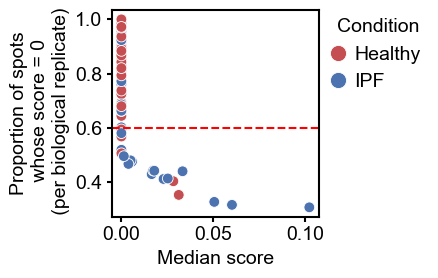

In [21]:


cond_labels = ["Healthy",'IPF']
cond_colors = custom_colors

# Scatter plot: std_score vs. mean_score (or any other columns)
fig, ax = plt.subplots(figsize=(4, 3))  # Can be any shape now
sns.scatterplot(data=interface_df.sample(frac =1 ,random_state=42), x='median_score', y='zero_fraction', hue='treatment',
                palette=dict(zip(cond_labels, cond_colors)), ax = ax, s= 60, hue_order = cond_labels)



plt.xlabel('Median score')
plt.ylabel('Proportion of spots\n whose score = 0\n (per biological replicate)')
plt.legend(title = "Condition", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False, markerscale=1.5, handlelength=0.1)
ax.set_box_aspect(1)

plt.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)


plt.tight_layout()
plt.savefig(os.path.join(save_dir,"zero_fraction_v_median_score_by_treatment.pdf"), bbox_inches='tight')
plt.show()

In [22]:
interface_df[interface_df['treatment']=="IPF"][
    interface_df[interface_df['treatment']=="IPF"]['zero_fraction'] < 0.70]['interface'].value_counts()

interface
Alveolar__Fibroblast               3
Alveolar__Fibrotic                 3
Alveolar__Immune                   3
Alveolar__SMCs_Adv_Meso            2
Fibroblast__Fibrotic               2
Fibroblast__Immune                 2
Fibroblast__SMCs_Adv_Meso          2
Immune__SMCs_Adv_Meso              2
Fibrotic__Immune                   2
Alveolar__Macrophage_FABP4         1
Fibroblast__Macrophage_FABP4       1
Macrophage_FABP4__SMCs_Adv_Meso    1
Fibrotic__SMCs_Adv_Meso            1
Name: count, dtype: int64

In [23]:
# Which interfaces are the most common across samples per condition?
top_interfaces_concat = pd.concat(
    [interface_df[interface_df['treatment']=="Healthy"][
    interface_df[interface_df['treatment']=="Healthy"]['zero_fraction'] < 0.60]['interface'].value_counts()/4,
    interface_df[interface_df['treatment']=="IPF"][
    interface_df[interface_df['treatment']=="IPF"]['zero_fraction'] < 0.60]['interface'].value_counts()/3
    ], axis=1, keys=['Healthy','IPF']
)

In [24]:
top_interfaces_concat

,Healthy,IPF
interface,,
Alveolar__Fibroblast,0.5,0.666667
Alveolar__SMCs_Adv_Meso,0.5,0.666667
Alveolar__Macrophage_FABP4,0.5,0.333333
Fibroblast__Immune,NaN,0.666667
Fibroblast__SMCs_Adv_Meso,NaN,0.666667
Alveolar__Fibrotic,NaN,0.666667
Alveolar__Immune,NaN,0.666667
Fibroblast__Macrophage_FABP4,NaN,0.333333
Fibrotic__Immune,NaN,0.333333


In [25]:
top_interfaces_concat_filled = top_interfaces_concat.fillna(0)

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_87523/3969846688.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


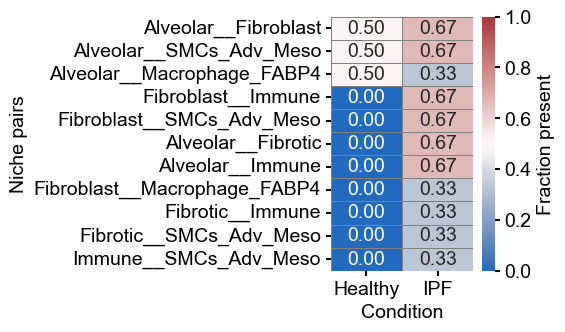

In [ ]:

fig, ax = plt.subplots(1,1,figsize=(2.3, 0.3 * len(top_interfaces_concat_filled)))  # adjust size as needed
sns.heatmap(
    top_interfaces_concat_filled,
    cmap="vlag",     
    vmin=0, vmax=1,      
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Fraction present"},
    ax = ax,
    annot=True,
    fmt = ".2f",
    annot_kws={"size":14}
    
)
plt.xlabel("Condition")
plt.ylabel("Niche pairs")
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"hm_top_interfaces_concat.pdf"), bbox_inches='tight', pad_inches=0.2)
plt.savefig(os.path.join(save_dir,"hm_top_interfaces_concat.png"), bbox_inches='tight', pad_inches=0.2, dpi = 1200, transparent = True)

plt.show()


In [ ]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn3, venn3_circles
import seaborn as sns

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_87523/2089156178.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['treatment'] = pd.Categorical(filtered_df['treatment'], categories=cond_order, ordered=True)


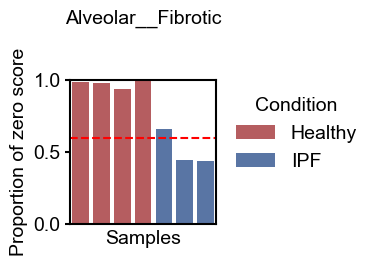

In [ ]:
target_interface = 'Alveolar__Fibrotic'

# Filter for the specific interface
filtered_df = interface_df[(interface_df['interface'] == target_interface)]

# Ensure cond is categorical with the desired order
cond_order = ['Healthy','IPF']
filtered_df['treatment'] = pd.Categorical(filtered_df['treatment'], categories=cond_order, ordered=True)

# Sort the dataframe by cond to ensure correct order of bars
filtered_df = filtered_df.sort_values('treatment')

# Create the barplot
plt.figure(figsize=(4, 2.8))
sns.barplot(
    data=filtered_df,
    x='sample',
    y='zero_fraction',
    hue='treatment',
    dodge=False,
    palette=custom_colors
)
plt.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

plt.title(f'{target_interface}', pad = 40)
plt.xlabel('Samples')
plt.ylabel('Proportion of zero score')

plt.ylim(0,1)
plt.xticks([])
plt.legend(title='Condition', bbox_to_anchor = (1.02, 1), frameon = False)
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"barplot_zero_frac_Alveolar__Fibrotic.pdf"), bbox_inches = 'tight')
plt.show()

In [ ]:
adata_vis.obs['Alveolar__Fibrotic']

spot_id
90_A1_H237762_IPF_processed_CM_AAACAAGTATCTCCCA-1    0.000000
90_A1_H237762_IPF_processed_CM_AAACACCAATAACTGC-1    0.092473
90_A1_H237762_IPF_processed_CM_AAACAGCTTTCAGAAG-1    0.148299
90_A1_H237762_IPF_processed_CM_AAACAGGGTCTATATT-1    0.000000
90_A1_H237762_IPF_processed_CM_AAACATTTCCCGGATT-1    0.000000
                                                       ...   
1217_0004_processed_aligned_TGTTGGTGAGCGGACG-1            NaN
1217_0004_processed_aligned_TGTTGGTGCGCACGAG-1            NaN
1217_0004_processed_aligned_TGTTGGTGCGCTTCGC-1            NaN
1217_0004_processed_aligned_TGTTGGTGCGGAATCA-1            NaN
1217_0004_processed_aligned_TGTTGGTGGACTCAGG-1            NaN
Name: Alveolar__Fibrotic, Length: 57787, dtype: float64

In [ ]:
adata_vis.obs['sample']

spot_id
90_A1_H237762_IPF_processed_CM_AAACAAGTATCTCCCA-1    90_A1_H237762_IPF_processed_CM
90_A1_H237762_IPF_processed_CM_AAACACCAATAACTGC-1    90_A1_H237762_IPF_processed_CM
90_A1_H237762_IPF_processed_CM_AAACAGCTTTCAGAAG-1    90_A1_H237762_IPF_processed_CM
90_A1_H237762_IPF_processed_CM_AAACAGGGTCTATATT-1    90_A1_H237762_IPF_processed_CM
90_A1_H237762_IPF_processed_CM_AAACATTTCCCGGATT-1    90_A1_H237762_IPF_processed_CM
                                                                  ...              
1217_0004_processed_aligned_TGTTGGTGAGCGGACG-1          1217_0004_processed_aligned
1217_0004_processed_aligned_TGTTGGTGCGCACGAG-1          1217_0004_processed_aligned
1217_0004_processed_aligned_TGTTGGTGCGCTTCGC-1          1217_0004_processed_aligned
1217_0004_processed_aligned_TGTTGGTGCGGAATCA-1          1217_0004_processed_aligned
1217_0004_processed_aligned_TGTTGGTGGACTCAGG-1          1217_0004_processed_aligned
Name: sample, Length: 57787, dtype: category
Categories (11, object)

In [ ]:
mapping_dict = dict(zip(adata_vis.obs["patient"], adata_vis.obs["sample"]))

In [ ]:
mapping_dict

{'Donor_IPF_1': '1217_0001_processed_aligned',
 'Donor_Control_2': '1217_0004_processed_aligned',
 'Donor_Control_1': '1217_0002_processed_aligned',
 'Donor_Control_4': '91_B1_RO-728_Healthy_processed_CM',
 'Donor_IPF_2': '1217_0003_processed_aligned',
 'Donor_IPF_3': '92_D1_RO-3736_IPF_processed_CM',
 'Donor_Control_3': '92_A1_RO-3203_Healthy_processed_CM'}

In [ ]:
adata_vis.obs['Alveolar']

spot_id
90_A1_H237762_IPF_processed_CM_AAACAAGTATCTCCCA-1    0.000000
90_A1_H237762_IPF_processed_CM_AAACACCAATAACTGC-1    3.705124
90_A1_H237762_IPF_processed_CM_AAACAGCTTTCAGAAG-1    3.263140
90_A1_H237762_IPF_processed_CM_AAACAGGGTCTATATT-1    0.000000
90_A1_H237762_IPF_processed_CM_AAACATTTCCCGGATT-1    0.000000
                                                       ...   
1217_0004_processed_aligned_TGTTGGTGAGCGGACG-1       4.090339
1217_0004_processed_aligned_TGTTGGTGCGCACGAG-1       1.073773
1217_0004_processed_aligned_TGTTGGTGCGCTTCGC-1       2.197537
1217_0004_processed_aligned_TGTTGGTGCGGAATCA-1       4.287530
1217_0004_processed_aligned_TGTTGGTGGACTCAGG-1       4.080682
Name: Alveolar, Length: 57787, dtype: float64

In [ ]:
adata_vis.obs['Alveolar__Fibrotic']

spot_id
90_A1_H237762_IPF_processed_CM_AAACAAGTATCTCCCA-1    0.000000
90_A1_H237762_IPF_processed_CM_AAACACCAATAACTGC-1    0.092473
90_A1_H237762_IPF_processed_CM_AAACAGCTTTCAGAAG-1    0.148299
90_A1_H237762_IPF_processed_CM_AAACAGGGTCTATATT-1    0.000000
90_A1_H237762_IPF_processed_CM_AAACATTTCCCGGATT-1    0.000000
                                                       ...   
1217_0004_processed_aligned_TGTTGGTGAGCGGACG-1            NaN
1217_0004_processed_aligned_TGTTGGTGCGCACGAG-1            NaN
1217_0004_processed_aligned_TGTTGGTGCGCTTCGC-1            NaN
1217_0004_processed_aligned_TGTTGGTGCGGAATCA-1            NaN
1217_0004_processed_aligned_TGTTGGTGGACTCAGG-1            NaN
Name: Alveolar__Fibrotic, Length: 57787, dtype: float64

In [ ]:
adata_vis.obs['Alveolar__Fibrotic'] = adata_vis.obs['Alveolar__Fibrotic'].fillna(0)

In [ ]:
adata_vis.obs['Alveolar'].dtype

dtype('float64')

In [ ]:
adata_vis[adata_vis.obs['patient']=="Donor_IPF_3"].obs['Alveolar__Fibrotic'].describe()

count    1931.000000
mean        0.106763
std         0.136210
min         0.000000
25%         0.000000
50%         0.033294
75%         0.189961
max         0.498851
Name: Alveolar__Fibrotic, dtype: float64